In [1]:
# Notebook 06: Quantum Hybrid Classifier
# Check environment and available PathoScope features

import os
import sys
import numpy as np
import pandas as pd
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DATA_DIR = "/content/drive/MyDrive/PathoScope/data"
WORK_DIR_06 = "/content/pathoscope_06"

os.makedirs(WORK_DIR_06, exist_ok=True)

print("\nData directory:")
print(DATA_DIR)

print("\nNotebook 06 working directory:")
print(WORK_DIR_06)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cpu
CUDA available: False

Data directory:
/content/drive/MyDrive/PathoScope/data

Notebook 06 working directory:
/content/pathoscope_06


In [2]:
from pathlib import Path

# Check Notebook 05 working directory
features_path = Path("/content/pathoscope_05/tile_features.pt")

print("Notebook 05 feature file:")
print(features_path)
print("Exists:", features_path.exists())

# Check Drive for Notebook 05 artifacts
drive_data = Path("/content/drive/MyDrive/PathoScope/data")

print("\nRelevant Drive files:")

for path in sorted(drive_data.glob("*")):
    if "feature" in path.name.lower() or "notebook_05" in path.name.lower():
        print(" -", path)

# Check current PyTorch objects if the previous notebook is still in memory
print("\nIn-memory objects:")

for name in [
    "all_features",
    "slide_features",
    "slide_labels",
    "train_indices",
    "val_indices",
    "test_indices"
]:
    print(f"{name}: {name in globals()}")

Notebook 05 feature file:
/content/pathoscope_05/tile_features.pt
Exists: False

Relevant Drive files:
 - /content/drive/MyDrive/PathoScope/data/notebook_05_results

In-memory objects:
all_features: False
slide_features: False
slide_labels: False
train_indices: False
val_indices: False
test_indices: False


In [3]:
from pathlib import Path

data_dir = Path("/content/drive/MyDrive/PathoScope/data")

print("PathoScope data contents:\n")

for path in sorted(data_dir.rglob("*")):

    if path.is_file():

        name = path.name.lower()

        if (
            "03" in str(path).lower()
            or "tile_clf" in name
            or "classification" in name
            or "feature" in name
            or name.endswith(".pth")
        ):
            size_mb = path.stat().st_size / (1024 ** 2)
            print(f"{path}  |  {size_mb:.2f} MB")

PathoScope data contents:

/content/drive/MyDrive/PathoScope/data/notebook_03_results/71abdfb52804bed1259c90f7b414e178_x512_y1024_gradcam.png  |  0.34 MB
/content/drive/MyDrive/PathoScope/data/notebook_03_results/model_comparison.csv  |  0.00 MB
/content/drive/MyDrive/PathoScope/data/notebook_03_results/tile_clf.pth  |  15.58 MB
/content/drive/MyDrive/PathoScope/data/notebook_03_results/tile_clf_densenet121.pth  |  27.13 MB
/content/drive/MyDrive/PathoScope/data/notebook_04_results/deeplabv3plus_resnet34.pth  |  257.07 MB
/content/drive/MyDrive/PathoScope/data/notebook_04_results/unet.pth  |  279.90 MB
/content/drive/MyDrive/PathoScope/data/notebook_04_results/unet_resnet50.pth  |  372.67 MB
/content/drive/MyDrive/PathoScope/data/notebook_04_results/unetpp_resnet34.pth  |  298.79 MB
/content/drive/MyDrive/PathoScope/data/notebook_05_results/combined_attention_mil.pth  |  1.51 MB
/content/drive/MyDrive/PathoScope/data/notebook_05_results/ordinal_attention_mil_classification_report.csv  

In [4]:
from pathlib import Path

data_dir = Path("/content/drive/MyDrive/PathoScope/data")

required = [
    "tiles.csv",
    "tiles_norm.zip",
    "tiles_img.zip"
]

print("Checking required files:\n")

for filename in required:

    path = data_dir / filename

    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"FOUND  {filename}  |  {size_mb:.2f} MB")
    else:
        print(f"MISSING  {filename}")

Checking required files:

FOUND  tiles.csv  |  2.85 MB
FOUND  tiles_norm.zip  |  411.67 MB
FOUND  tiles_img.zip  |  339.33 MB


In [5]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("Searching for PathoScope files...\n")

matches = []

for path in drive_root.rglob("*"):

    if path.is_file():

        name = path.name.lower()

        if (
            name in [
                "tiles.csv",
                "tiles_norm.zip",
                "tiles_img.zip",
                "ref_stain.npz"
            ]
            or "tile_clf" in name
            or "notebook_03" in str(path).lower()
            or "notebook_02" in str(path).lower()
            or "pathoscope" in str(path).lower()
        ):
            matches.append(path)

if matches:

    for path in matches:
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"{path}  |  {size_mb:.2f} MB")

else:
    print("No matching PathoScope files found.")

Searching for PathoScope files...

/content/drive/MyDrive/PathoScope/data/ref_stain.npz  |  0.00 MB
/content/drive/MyDrive/PathoScope/data/benchmark_stainnorm.json  |  0.00 MB
/content/drive/MyDrive/PathoScope/data/tiles.csv  |  2.85 MB
/content/drive/MyDrive/PathoScope/data/tiles_mask.zip  |  6.17 MB
/content/drive/MyDrive/PathoScope/data/tiles_norm.zip  |  411.67 MB
/content/drive/MyDrive/PathoScope/data/tiles_img.zip  |  339.33 MB
/content/drive/MyDrive/PathoScope/data/notebook_03_results/model_comparison.csv  |  0.00 MB
/content/drive/MyDrive/PathoScope/data/notebook_03_results/71abdfb52804bed1259c90f7b414e178_x512_y1024_gradcam.png  |  0.34 MB
/content/drive/MyDrive/PathoScope/data/notebook_03_results/tile_clf.pth  |  15.58 MB
/content/drive/MyDrive/PathoScope/data/notebook_03_results/tile_clf_densenet121.pth  |  27.13 MB
/content/drive/MyDrive/PathoScope/data/notebook_04_results/unet.pth  |  279.90 MB
/content/drive/MyDrive/PathoScope/data/notebook_04_results/unet_resnet50.pth  |

In [6]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("Searching for tiles.csv and tiles_norm.zip...\n")

for filename in ["tiles.csv", "tiles_norm.zip"]:

    matches = list(drive_root.rglob(filename))

    print(f"{filename}:")

    if matches:
        for path in matches:
            size_gb = path.stat().st_size / (1024 ** 3)
            print(f"  FOUND: {path}")
            print(f"  SIZE : {size_gb:.3f} GB")
    else:
        print("  NOT FOUND")

    print()

Searching for tiles.csv and tiles_norm.zip...

tiles.csv:
  FOUND: /content/drive/MyDrive/PathoScope/data/tiles.csv
  SIZE : 0.003 GB

tiles_norm.zip:
  FOUND: /content/drive/MyDrive/PathoScope/data/tiles_norm.zip
  SIZE : 0.402 GB



In [8]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/PathoScope/data")
WORK_DIR_06 = Path("/content/pathoscope_06")

WORK_DIR_06.mkdir(parents=True, exist_ok=True)

tiles_df = pd.read_csv(DATA_DIR / "tiles.csv")

print("tiles.csv shape:", tiles_df.shape)

print("\nColumns:")
print(tiles_df.columns.tolist())

print("\nUnique slides:", tiles_df["image_id"].nunique())

print("\nTiles per slide:")
print(
    tiles_df.groupby("image_id").size().value_counts().sort_index()
)

print("\nISUP distribution:")
print(
    tiles_df.groupby("image_id")["isup_grade"]
    .first()
    .value_counts()
    .sort_index()
)

tiles.csv shape: (12800, 13)

Columns:
['tile_id', 'image_id', 'data_provider', 'x', 'y', 'tile_size', 'tissue_fraction', 'tile_label', 'isup_grade', 'gleason_score', 'mask_available', 'image_path', 'mask_path']

Unique slides: 200

Tiles per slide:
64    200
Name: count, dtype: int64

ISUP distribution:
isup_grade
0    55
1    50
2    25
3    23
4    24
5    23
Name: count, dtype: int64


In [9]:
import zipfile
from pathlib import Path

norm_zip = DATA_DIR / "tiles_norm.zip"
norm_dir = WORK_DIR_06 / "tiles_norm"

norm_dir.mkdir(parents=True, exist_ok=True)

print("ZIP file:", norm_zip)
print("ZIP size:", f"{norm_zip.stat().st_size / (1024**3):.3f} GB")

with zipfile.ZipFile(norm_zip, "r") as z:
    members = z.namelist()

    print("Files in ZIP:", len(members))
    print("First 5 files:")
    for name in members[:5]:
        print(" ", name)

    z.extractall(norm_dir)

print("\nExtraction complete.")

image_files = [
    p for p in norm_dir.rglob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

print("Extracted image files:", len(image_files))

print("\nFirst 5 extracted images:")
for path in image_files[:5]:
    print(path)


ZIP file: /content/drive/MyDrive/PathoScope/data/tiles_norm.zip
ZIP size: 0.402 GB
Files in ZIP: 12800
First 5 files:
  008069b542b0439ed69b194674051964_x10240_y2048.jpg
  008069b542b0439ed69b194674051964_x10752_y2048.jpg
  008069b542b0439ed69b194674051964_x11008_y2560.jpg
  008069b542b0439ed69b194674051964_x11776_y2304.jpg
  008069b542b0439ed69b194674051964_x11776_y2560.jpg

Extraction complete.
Extracted image files: 12800

First 5 extracted images:
/content/pathoscope_06/tiles_norm/dd1c5062a0c646d6af4d2d77b4129db4_x768_y17152.jpg
/content/pathoscope_06/tiles_norm/ba2a37a47b802c46d8b931247e9d04fc_x3584_y12032.jpg
/content/pathoscope_06/tiles_norm/117e082dcd41f3e3244100693ceef2b8_x25600_y2816.jpg
/content/pathoscope_06/tiles_norm/fe8b4d94ce299ed485c900f05ae508d3_x15872_y4864.jpg
/content/pathoscope_06/tiles_norm/31f51b7b36414dc9f0ddda7cac67328f_x1536_y25088.jpg


In [10]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# Same EfficientNet-B0 backbone used for PathoScope slide grading
weights = EfficientNet_B0_Weights.DEFAULT

efficientnet = efficientnet_b0(weights=weights)

# Remove the final classification layer
efficientnet.classifier = nn.Identity()

efficientnet = efficientnet.to(device)
efficientnet.eval()

print("Model: EfficientNet-B0")
print("Output feature dimension:", 1280)

total_params = sum(
    p.numel()
    for p in efficientnet.parameters()
)

print("Total parameters:", total_params)

Device: cpu
Model: EfficientNet-B0
Output feature dimension: 1280
Total parameters: 4007548


In [11]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
import numpy as np

# Keep the exact tile ordering from tiles.csv
tile_paths = [
    WORK_DIR_06 / "tiles_norm" / Path(p).name
    for p in tiles_df["image_path"]
]

missing = [
    p for p in tile_paths
    if not p.exists()
]

print("Total tiles:", len(tile_paths))
print("Missing tiles:", len(missing))

if missing:
    print("\nFirst missing files:")
    for p in missing[:5]:
        print(p)
    raise FileNotFoundError("Some normalized tiles are missing.")

weights = EfficientNet_B0_Weights.DEFAULT
transform = weights.transforms()


class PathoScopeTileDataset(Dataset):

    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        image = transform(image)
        return image


dataset = PathoScopeTileDataset(tile_paths)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

all_features = []

print("\nExtracting EfficientNet-B0 features...")

with torch.no_grad():

    for batch in tqdm(loader):

        batch = batch.to(device)

        features = efficientnet(batch)

        all_features.append(
            features.cpu()
        )

all_features = torch.cat(
    all_features,
    dim=0
)

print("\nFeature extraction complete.")
print("Feature tensor shape:", all_features.shape)
print("Expected:", (12800, 1280))
print("Data type:", all_features.dtype)
print(
    "Feature range:",
    float(all_features.min()),
    "to",
    float(all_features.max())
)

Total tiles: 12800
Missing tiles: 0

Extracting EfficientNet-B0 features...


  0%|          | 0/400 [00:00<?, ?it/s]


Feature extraction complete.
Feature tensor shape: torch.Size([12800, 1280])
Expected: (12800, 1280)
Data type: torch.float32
Feature range: -0.2751368582248688 to 6.104122638702393


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Build one 1280-D representation for each slide
slide_features_06 = []

slide_labels_06 = []

slide_ids_06 = []

for image_id, group in tiles_df.groupby("image_id", sort=False):

    group = group.sort_values("tile_id")

    tile_indices = group.index.to_numpy()

    tile_features = all_features[tile_indices]

    # Mean of the 64 tile feature vectors
    slide_feature = tile_features.mean(dim=0)

    slide_features_06.append(
        slide_feature
    )

    slide_labels_06.append(
        int(group["isup_grade"].iloc[0])
    )

    slide_ids_06.append(
        image_id
    )

slide_features_06 = torch.stack(
    slide_features_06
)

slide_labels_06 = np.array(
    slide_labels_06
)

print("Slide feature shape:")
print(slide_features_06.shape)

print("\nSlide labels shape:")
print(slide_labels_06.shape)

print("\nISUP distribution:")
print(
    pd.Series(slide_labels_06)
    .value_counts()
    .sort_index()
)

# Convert to NumPy for PCA
X_slides = slide_features_06.numpy()

# Standardize before PCA
scaler_06 = StandardScaler()

X_scaled_06 = scaler_06.fit_transform(
    X_slides
)

# Reduce 1280 dimensions → 8 dimensions
pca_06 = PCA(
    n_components=8,
    random_state=42
)

X_pca_06 = pca_06.fit_transform(
    X_scaled_06
)

print("\nPCA feature shape:")
print(X_pca_06.shape)

print("\nExplained variance ratio:")
print(pca_06.explained_variance_ratio_)

print(
    "\nTotal variance explained by 8 components:",
    pca_06.explained_variance_ratio_.sum()
)

Slide feature shape:
torch.Size([200, 1280])

Slide labels shape:
(200,)

ISUP distribution:
0    55
1    50
2    25
3    23
4    24
5    23
Name: count, dtype: int64

PCA feature shape:
(200, 8)

Explained variance ratio:
[0.1920617  0.12863904 0.09698243 0.07457089 0.04103369 0.036876
 0.03355247 0.03094934]

Total variance explained by 8 components: 0.6346656


In [13]:
from sklearn.model_selection import train_test_split

# Recreate the same stratified 140/30/30 slide split
slide_indices = np.arange(len(slide_labels_06))

train_idx_06, temp_idx_06 = train_test_split(
    slide_indices,
    test_size=60,
    stratify=slide_labels_06,
    random_state=42
)

val_idx_06, test_idx_06 = train_test_split(
    temp_idx_06,
    test_size=30,
    stratify=slide_labels_06[temp_idx_06],
    random_state=42
)

print("Split sizes:")
print("Train:", len(train_idx_06))
print("Validation:", len(val_idx_06))
print("Test:", len(test_idx_06))

print("\nTrain ISUP distribution:")
print(
    pd.Series(slide_labels_06[train_idx_06])
    .value_counts()
    .sort_index()
)

print("\nValidation ISUP distribution:")
print(
    pd.Series(slide_labels_06[val_idx_06])
    .value_counts()
    .sort_index()
)

print("\nTest ISUP distribution:")
print(
    pd.Series(slide_labels_06[test_idx_06])
    .value_counts()
    .sort_index()
)

# Fit scaler ONLY on training slides
scaler_06 = StandardScaler()

X_train_scaled = scaler_06.fit_transform(
    X_slides[train_idx_06]
)

X_val_scaled = scaler_06.transform(
    X_slides[val_idx_06]
)

X_test_scaled = scaler_06.transform(
    X_slides[test_idx_06]
)

# Fit PCA ONLY on training slides
pca_06 = PCA(
    n_components=8,
    random_state=42
)

X_train_pca = pca_06.fit_transform(
    X_train_scaled
)

X_val_pca = pca_06.transform(
    X_val_scaled
)

X_test_pca = pca_06.transform(
    X_test_scaled
)

print("\nPCA shapes:")
print("Train:", X_train_pca.shape)
print("Validation:", X_val_pca.shape)
print("Test:", X_test_pca.shape)

print(
    "\nTraining variance explained:",
    pca_06.explained_variance_ratio_.sum()
)

Split sizes:
Train: 140
Validation: 30
Test: 30

Train ISUP distribution:
0    38
1    35
2    18
3    16
4    17
5    16
Name: count, dtype: int64

Validation ISUP distribution:
0    9
1    8
2    3
3    3
4    3
5    4
Name: count, dtype: int64

Test ISUP distribution:
0    8
1    7
2    4
3    4
4    4
5    3
Name: count, dtype: int64

PCA shapes:
Train: (140, 8)
Validation: (30, 8)
Test: (30, 8)

Training variance explained: 0.64034474


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_train_06 = slide_labels_06[train_idx_06]
y_val_06 = slide_labels_06[val_idx_06]
y_test_06 = slide_labels_06[test_idx_06]

logreg_06 = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    random_state=42
)

logreg_06.fit(
    X_train_pca,
    y_train_06
)

# Predictions
logreg_val_pred = logreg_06.predict(X_val_pca)
logreg_test_pred = logreg_06.predict(X_test_pca)

# Probabilities
logreg_val_prob = logreg_06.predict_proba(X_val_pca)
logreg_test_prob = logreg_06.predict_proba(X_test_pca)

# Metrics
logreg_val_acc = accuracy_score(
    y_val_06,
    logreg_val_pred
)

logreg_test_acc = accuracy_score(
    y_test_06,
    logreg_test_pred
)

logreg_val_f1 = f1_score(
    y_val_06,
    logreg_val_pred,
    average="macro"
)

logreg_test_f1 = f1_score(
    y_test_06,
    logreg_test_pred,
    average="macro"
)

logreg_val_auc = roc_auc_score(
    y_val_06,
    logreg_val_prob,
    multi_class="ovr",
    average="macro"
)

logreg_test_auc = roc_auc_score(
    y_test_06,
    logreg_test_prob,
    multi_class="ovr",
    average="macro"
)

print("Logistic Regression — 8 PCA Features")
print("--------------------------------------")
print(f"Validation Accuracy : {logreg_val_acc:.4f}")
print(f"Validation Macro F1 : {logreg_val_f1:.4f}")
print(f"Validation Macro AUC: {logreg_val_auc:.4f}")

print(f"\nTest Accuracy       : {logreg_test_acc:.4f}")
print(f"Test Macro F1       : {logreg_test_f1:.4f}")
print(f"Test Macro AUC      : {logreg_test_auc:.4f}")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test_06,
        logreg_test_pred,
        labels=[0, 1, 2, 3, 4, 5],
        target_names=[
            "ISUP 0",
            "ISUP 1",
            "ISUP 2",
            "ISUP 3",
            "ISUP 4",
            "ISUP 5"
        ],
        zero_division=0
    )
)


Logistic Regression — 8 PCA Features
--------------------------------------
Validation Accuracy : 0.3000
Validation Macro F1 : 0.1898
Validation Macro AUC: 0.6785

Test Accuracy       : 0.3667
Test Macro F1       : 0.3272
Test Macro AUC      : 0.7283

Test Classification Report:
              precision    recall  f1-score   support

      ISUP 0       0.33      0.25      0.29         8
      ISUP 1       0.45      0.71      0.56         7
      ISUP 2       0.50      0.50      0.50         4
      ISUP 3       0.20      0.25      0.22         4
      ISUP 4       0.00      0.00      0.00         4
      ISUP 5       0.50      0.33      0.40         3

    accuracy                           0.37        30
   macro avg       0.33      0.34      0.33        30
weighted avg       0.34      0.37      0.34        30



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [15]:
from sklearn.neural_network import MLPClassifier

mlp_06 = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=30,
    random_state=42
)

mlp_06.fit(
    X_train_pca,
    y_train_06
)

# Predictions
mlp_val_pred = mlp_06.predict(X_val_pca)
mlp_test_pred = mlp_06.predict(X_test_pca)

# Probabilities
mlp_val_prob = mlp_06.predict_proba(X_val_pca)
mlp_test_prob = mlp_06.predict_proba(X_test_pca)

# Metrics
mlp_val_acc = accuracy_score(
    y_val_06,
    mlp_val_pred
)

mlp_test_acc = accuracy_score(
    y_test_06,
    mlp_test_pred
)

mlp_val_f1 = f1_score(
    y_val_06,
    mlp_val_pred,
    average="macro"
)

mlp_test_f1 = f1_score(
    y_test_06,
    mlp_test_pred,
    average="macro"
)

mlp_val_auc = roc_auc_score(
    y_val_06,
    mlp_val_prob,
    multi_class="ovr",
    average="macro"
)

mlp_test_auc = roc_auc_score(
    y_test_06,
    mlp_test_prob,
    multi_class="ovr",
    average="macro"
)

print("MLP — 8 PCA Features")
print("---------------------")
print(f"Validation Accuracy : {mlp_val_acc:.4f}")
print(f"Validation Macro F1 : {mlp_val_f1:.4f}")
print(f"Validation Macro AUC: {mlp_val_auc:.4f}")

print(f"\nTest Accuracy       : {mlp_test_acc:.4f}")
print(f"Test Macro F1       : {mlp_test_f1:.4f}")
print(f"Test Macro AUC      : {mlp_test_auc:.4f}")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test_06,
        mlp_test_pred,
        labels=[0, 1, 2, 3, 4, 5],
        target_names=[
            "ISUP 0",
            "ISUP 1",
            "ISUP 2",
            "ISUP 3",
            "ISUP 4",
            "ISUP 5"
        ],
        zero_division=0
    )
)

MLP — 8 PCA Features
---------------------
Validation Accuracy : 0.2000
Validation Macro F1 : 0.0571
Validation Macro AUC: 0.3424

Test Accuracy       : 0.2333
Test Macro F1       : 0.1082
Test Macro AUC      : 0.4797

Test Classification Report:
              precision    recall  f1-score   support

      ISUP 0       0.24      0.75      0.36         8
      ISUP 1       0.00      0.00      0.00         7
      ISUP 2       0.00      0.00      0.00         4
      ISUP 3       0.33      0.25      0.29         4
      ISUP 4       0.00      0.00      0.00         4
      ISUP 5       0.00      0.00      0.00         3

    accuracy                           0.23        30
   macro avg       0.10      0.17      0.11        30
weighted avg       0.11      0.23      0.14        30



In [16]:
!pip -q install pennylane

import pennylane as qml
import torch
import numpy as np

print("PennyLane version:", qml.__version__)
print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)

print("Quantum device:")
dev_06 = qml.device(
    "default.qubit",
    wires=8
)

print(dev_06)

PennyLane version: 0.45.1
PyTorch version: 2.11.0+cpu
NumPy version: 2.5.3
Quantum device:
<default.qubit device (wires=8) at 0x78226a9ff770>


In [19]:
import torch
import torch.nn as nn
import pennylane as qml

class QuantumHybridClassifier06(nn.Module):
    def __init__(self, n_qubits=8, n_layers=3, n_classes=6):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.dev = qml.device(
            "default.qubit",
            wires=n_qubits
        )

        weight_shape = qml.StronglyEntanglingLayers.shape(
            n_layers=n_layers,
            n_wires=n_qubits
        )

        self.quantum_weights = nn.Parameter(
            0.01 * torch.randn(weight_shape)
        )

        @qml.qnode(
            self.dev,
            interface="torch",
            diff_method="backprop"
        )
        def circuit(inputs, weights):

            qml.AngleEmbedding(
                inputs,
                wires=range(n_qubits),
                rotation="Y"
            )

            qml.StronglyEntanglingLayers(
                weights,
                wires=range(n_qubits)
            )

            return [
                qml.expval(qml.PauliZ(i))
                for i in range(n_qubits)
            ]

        self.circuit = circuit

        # Linear head: 8 quantum outputs -> 6 ISUP classes
        self.classifier = nn.Linear(
            n_qubits,
            n_classes
        )

    def forward(self, x):

        quantum_outputs = []

        for sample in x:
            q_out = self.circuit(
                sample,
                self.quantum_weights
            )

            q_out = torch.stack(q_out).float()
            quantum_outputs.append(q_out)

        quantum_outputs = torch.stack(
            quantum_outputs
        )

        logits = self.classifier(
            quantum_outputs
        )

        return logits


quantum_model_06 = QuantumHybridClassifier06(
    n_qubits=8,
    n_layers=3,
    n_classes=6
)

total_params_06 = sum(
    p.numel()
    for p in quantum_model_06.parameters()
    if p.requires_grad
)

print(quantum_model_06)
print("\nTotal trainable parameters:", total_params_06)
print("Quantum parameters:", quantum_model_06.quantum_weights.numel())
print("Linear head parameters:", sum(
    p.numel()
    for p in quantum_model_06.classifier.parameters()
))

QuantumHybridClassifier06(
  (classifier): Linear(in_features=8, out_features=6, bias=True)
)

Total trainable parameters: 126
Quantum parameters: 72
Linear head parameters: 54


In [21]:
import torch
import torch.nn as nn
import numpy as np

X_train_q_06 = torch.tensor(
    X_train_pca,
    dtype=torch.float32
)

X_val_q_06 = torch.tensor(
    X_val_pca,
    dtype=torch.float32
)

X_test_q_06 = torch.tensor(
    X_test_pca,
    dtype=torch.float32
)

y_train_q_06 = torch.tensor(
    y_train_06,
    dtype=torch.long
)

y_val_q_06 = torch.tensor(
    y_val_06,
    dtype=torch.long
)

y_test_q_06 = torch.tensor(
    y_test_06,
    dtype=torch.long
)

criterion_q_06 = nn.CrossEntropyLoss()

optimizer_q_06 = torch.optim.Adam(
    quantum_model_06.parameters(),
    lr=0.01
)

print("Train:", X_train_q_06.shape, y_train_q_06.shape)
print("Validation:", X_val_q_06.shape, y_val_q_06.shape)
print("Test:", X_test_q_06.shape, y_test_q_06.shape)

print("\nStarting 3-epoch quantum training test...")

for epoch in range(3):

    quantum_model_06.train()

    optimizer_q_06.zero_grad()

    train_logits = quantum_model_06(
        X_train_q_06
    )

    train_loss = criterion_q_06(
        train_logits,
        y_train_q_06
    )

    train_loss.backward()
    optimizer_q_06.step()

    with torch.no_grad():

        quantum_model_06.eval()

        val_logits = quantum_model_06(
            X_val_q_06
        )

        val_loss = criterion_q_06(
            val_logits,
            y_val_q_06
        )

        val_pred = torch.argmax(
            val_logits,
            dim=1
        )

        val_acc = (
            val_pred == y_val_q_06
        ).float().mean().item()

    print(
        f"Epoch {epoch + 1}/3 | "
        f"Train Loss: {train_loss.item():.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Train: torch.Size([140, 8]) torch.Size([140])
Validation: torch.Size([30, 8]) torch.Size([30])
Test: torch.Size([30, 8]) torch.Size([30])

Starting 3-epoch quantum training test...
Epoch 1/3 | Train Loss: 1.8405 | Val Loss: 1.8015 | Val Acc: 0.1667
Epoch 2/3 | Train Loss: 1.8323 | Val Loss: 1.7973 | Val Acc: 0.1667
Epoch 3/3 | Train Loss: 1.8243 | Val Loss: 1.7932 | Val Acc: 0.1667


In [22]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch

# Fit the angle scaler only on training data
angle_scaler_06 = MinMaxScaler(
    feature_range=(-np.pi, np.pi)
)

X_train_angle_06 = angle_scaler_06.fit_transform(
    X_train_pca
)

X_val_angle_06 = angle_scaler_06.transform(
    X_val_pca
)

X_test_angle_06 = angle_scaler_06.transform(
    X_test_pca
)

# Convert to PyTorch tensors
X_train_angle_q_06 = torch.tensor(
    X_train_angle_06,
    dtype=torch.float32
)

X_val_angle_q_06 = torch.tensor(
    X_val_angle_06,
    dtype=torch.float32
)

X_test_angle_q_06 = torch.tensor(
    X_test_angle_06,
    dtype=torch.float32
)

print("Training angle range:")
print(
    X_train_angle_06.min(),
    "to",
    X_train_angle_06.max()
)

print("\nValidation angle range:")
print(
    X_val_angle_06.min(),
    "to",
    X_val_angle_06.max()
)

print("\nTest angle range:")
print(
    X_test_angle_06.min(),
    "to",
    X_test_angle_06.max()
)

print("\nShapes:")
print("Train:", X_train_angle_q_06.shape)
print("Validation:", X_val_angle_q_06.shape)
print("Test:", X_test_angle_q_06.shape)

Training angle range:
-3.1415927 to 3.141593

Validation angle range:
-3.920078 to 2.764826

Test angle range:
-3.349411 to 3.353119

Shapes:
Train: torch.Size([140, 8])
Validation: torch.Size([30, 8])
Test: torch.Size([30, 8])


In [23]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import copy
import torch

# Reinitialize the quantum model
quantum_model_06 = QuantumHybridClassifier06(
    n_qubits=8,
    n_layers=3,
    n_classes=6
)

criterion_q_06 = torch.nn.CrossEntropyLoss()

optimizer_q_06 = torch.optim.Adam(
    quantum_model_06.parameters(),
    lr=0.01
)

best_val_f1_q_06 = -1.0
best_val_auc_q_06 = -1.0
best_epoch_q_06 = 0
best_state_q_06 = None

history_q_06 = []

print("Starting VQC training...")
print("Epochs: 20")
print("Training samples:", len(X_train_angle_q_06))
print()

for epoch in range(20):

    quantum_model_06.train()

    optimizer_q_06.zero_grad()

    train_logits = quantum_model_06(
        X_train_angle_q_06
    )

    train_loss = criterion_q_06(
        train_logits,
        y_train_q_06
    )

    train_loss.backward()
    optimizer_q_06.step()

    # Validation
    quantum_model_06.eval()

    with torch.no_grad():

        val_logits = quantum_model_06(
            X_val_angle_q_06
        )

        val_prob = torch.softmax(
            val_logits,
            dim=1
        ).cpu().numpy()

        val_pred = np.argmax(
            val_prob,
            axis=1
        )

    val_acc = accuracy_score(
        y_val_06,
        val_pred
    )

    val_f1 = f1_score(
        y_val_06,
        val_pred,
        average="macro"
    )

    val_auc = roc_auc_score(
        y_val_06,
        val_prob,
        multi_class="ovr",
        average="macro"
    )

    history_q_06.append({
        "epoch": epoch + 1,
        "train_loss": train_loss.item(),
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "val_macro_auc": val_auc
    })

    if val_f1 > best_val_f1_q_06:

        best_val_f1_q_06 = val_f1
        best_val_auc_q_06 = val_auc
        best_epoch_q_06 = epoch + 1

        best_state_q_06 = copy.deepcopy(
            quantum_model_06.state_dict()
        )

    print(
        f"Epoch {epoch + 1:02d}/20 | "
        f"Train Loss: {train_loss.item():.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

# Restore best validation model
quantum_model_06.load_state_dict(
    best_state_q_06
)

print("\nBest validation epoch:", best_epoch_q_06)
print("Best validation Macro F1:", f"{best_val_f1_q_06:.4f}")
print("Best validation Macro AUC:", f"{best_val_auc_q_06:.4f}")


Starting VQC training...
Epochs: 20
Training samples: 140

Epoch 01/20 | Train Loss: 1.8819 | Val Acc: 0.1667 | Val F1: 0.1357 | Val AUC: 0.4339
Epoch 02/20 | Train Loss: 1.8725 | Val Acc: 0.1667 | Val F1: 0.1357 | Val AUC: 0.4386
Epoch 03/20 | Train Loss: 1.8633 | Val Acc: 0.1667 | Val F1: 0.1357 | Val AUC: 0.4347
Epoch 04/20 | Train Loss: 1.8543 | Val Acc: 0.1333 | Val F1: 0.1124 | Val AUC: 0.4353
Epoch 05/20 | Train Loss: 1.8454 | Val Acc: 0.1333 | Val F1: 0.1124 | Val AUC: 0.4391
Epoch 06/20 | Train Loss: 1.8368 | Val Acc: 0.1000 | Val F1: 0.0611 | Val AUC: 0.4350
Epoch 07/20 | Train Loss: 1.8284 | Val Acc: 0.1000 | Val F1: 0.0556 | Val AUC: 0.4394
Epoch 08/20 | Train Loss: 1.8201 | Val Acc: 0.1000 | Val F1: 0.0556 | Val AUC: 0.4412
Epoch 09/20 | Train Loss: 1.8120 | Val Acc: 0.1000 | Val F1: 0.0556 | Val AUC: 0.4464
Epoch 10/20 | Train Loss: 1.8041 | Val Acc: 0.1000 | Val F1: 0.0581 | Val AUC: 0.4468
Epoch 11/20 | Train Loss: 1.7963 | Val Acc: 0.1000 | Val F1: 0.0595 | Val AUC: 0.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)

quantum_model_06.eval()

with torch.no_grad():

    test_logits_q_06 = quantum_model_06(
        X_test_angle_q_06
    )

    test_prob_q_06 = torch.softmax(
        test_logits_q_06,
        dim=1
    ).cpu().numpy()

    test_pred_q_06 = np.argmax(
        test_prob_q_06,
        axis=1
    )

vqc_test_acc_06 = accuracy_score(
    y_test_06,
    test_pred_q_06
)

vqc_test_f1_06 = f1_score(
    y_test_06,
    test_pred_q_06,
    average="macro"
)

vqc_test_auc_06 = roc_auc_score(
    y_test_06,
    test_prob_q_06,
    multi_class="ovr",
    average="macro"
)

print("VQC — 8 Qubits")
print("----------------")
print(f"Test Accuracy : {vqc_test_acc_06:.4f}")
print(f"Test Macro F1 : {vqc_test_f1_06:.4f}")
print(f"Test Macro AUC: {vqc_test_auc_06:.4f}")

print("\nTest Classification Report:")
print(
    classification_report(
        y_test_06,
        test_pred_q_06,
        labels=[0, 1, 2, 3, 4, 5],
        target_names=[
            "ISUP 0",
            "ISUP 1",
            "ISUP 2",
            "ISUP 3",
            "ISUP 4",
            "ISUP 5"
        ],
        zero_division=0
    )
)


VQC — 8 Qubits
----------------
Test Accuracy : 0.2333
Test Macro F1 : 0.2191
Test Macro AUC: 0.5887

Test Classification Report:
              precision    recall  f1-score   support

      ISUP 0       0.00      0.00      0.00         8
      ISUP 1       0.20      0.29      0.24         7
      ISUP 2       0.67      0.50      0.57         4
      ISUP 3       0.00      0.00      0.00         4
      ISUP 4       0.20      0.50      0.29         4
      ISUP 5       0.17      0.33      0.22         3

    accuracy                           0.23        30
   macro avg       0.21      0.27      0.22        30
weighted avg       0.18      0.23      0.19        30



In [25]:
import pandas as pd

comparison_06 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "MLP",
        "VQC (8 qubits)"
    ],
    "Test Accuracy": [
        logreg_test_acc,
        mlp_test_acc,
        vqc_test_acc_06
    ],
    "Test Macro F1": [
        logreg_test_f1,
        mlp_test_f1,
        vqc_test_f1_06
    ],
    "Test Macro AUC": [
        logreg_test_auc,
        mlp_test_auc,
        vqc_test_auc_06
    ]
})

comparison_06 = comparison_06.round(4)

print("PathoScope — Classical vs Quantum")
print(comparison_06.to_string(index=False))

print("\nValidation results:")
print(
    f"Logistic Regression: "
    f"Acc={logreg_val_acc:.4f}, "
    f"F1={logreg_val_f1:.4f}, "
    f"AUC={logreg_val_auc:.4f}"
)

print(
    f"MLP: "
    f"Acc={mlp_val_acc:.4f}, "
    f"F1={mlp_val_f1:.4f}, "
    f"AUC={mlp_val_auc:.4f}"
)

print(
    f"VQC: "
    f"Acc={best_val_f1_q_06:.4f}* "
    f"(best epoch={best_epoch_q_06}), "
    f"F1={best_val_f1_q_06:.4f}, "
    f"AUC={best_val_auc_q_06:.4f}"
)

PathoScope — Classical vs Quantum
              Model  Test Accuracy  Test Macro F1  Test Macro AUC
Logistic Regression         0.3667         0.3272          0.7283
                MLP         0.2333         0.1082          0.4797
     VQC (8 qubits)         0.2333         0.2191          0.5887

Validation results:
Logistic Regression: Acc=0.3000, F1=0.1898, AUC=0.6785
MLP: Acc=0.2000, F1=0.0571, AUC=0.3424
VQC: Acc=0.1578* (best epoch=19), F1=0.1578, AUC=0.4718


In [26]:
# Correct VQC validation metrics from the training history
vqc_best_row_06 = history_q_06[
    best_epoch_q_06 - 1
]

vqc_val_acc_06 = vqc_best_row_06["val_accuracy"]
vqc_val_f1_06 = vqc_best_row_06["val_macro_f1"]
vqc_val_auc_06 = vqc_best_row_06["val_macro_auc"]

final_results_06 = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "MLP",
        "VQC (8 qubits)"
    ],

    "Validation Accuracy": [
        logreg_val_acc,
        mlp_val_acc,
        vqc_val_acc_06
    ],

    "Validation Macro F1": [
        logreg_val_f1,
        mlp_val_f1,
        vqc_val_f1_06
    ],

    "Validation Macro AUC": [
        logreg_val_auc,
        mlp_val_auc,
        vqc_val_auc_06
    ],

    "Test Accuracy": [
        logreg_test_acc,
        mlp_test_acc,
        vqc_test_acc_06
    ],

    "Test Macro F1": [
        logreg_test_f1,
        mlp_test_f1,
        vqc_test_f1_06
    ],

    "Test Macro AUC": [
        logreg_test_auc,
        mlp_test_auc,
        vqc_test_auc_06
    ]
})

final_results_06 = final_results_06.round(4)

print("PathoScope — Notebook 06 Final Comparison")
print("=" * 50)
print(final_results_06.to_string(index=False))

print("\nVQC best validation epoch:", best_epoch_q_06)
print(f"VQC validation accuracy : {vqc_val_acc_06:.4f}")
print(f"VQC validation Macro F1 : {vqc_val_f1_06:.4f}")
print(f"VQC validation Macro AUC: {vqc_val_auc_06:.4f}")

PathoScope — Notebook 06 Final Comparison
              Model  Validation Accuracy  Validation Macro F1  Validation Macro AUC  Test Accuracy  Test Macro F1  Test Macro AUC
Logistic Regression               0.3000               0.1898                0.6785         0.3667         0.3272          0.7283
                MLP               0.2000               0.0571                0.3424         0.2333         0.1082          0.4797
     VQC (8 qubits)               0.2333               0.1578                0.4718         0.2333         0.2191          0.5887

VQC best validation epoch: 19
VQC validation accuracy : 0.2333
VQC validation Macro F1 : 0.1578
VQC validation Macro AUC: 0.4718


In [27]:
from pathlib import Path

results_dir_06 = Path(
    "/content/drive/MyDrive/PathoScope/data/notebook_06_results"
)

results_dir_06.mkdir(
    parents=True,
    exist_ok=True
)

# Save model comparison
comparison_path_06 = (
    results_dir_06 / "quantum_vs_classical_results.csv"
)

final_results_06.to_csv(
    comparison_path_06,
    index=False
)

# Save VQC training history
history_df_06 = pd.DataFrame(
    history_q_06
)

history_path_06 = (
    results_dir_06 / "vqc_training_history.csv"
)

history_df_06.to_csv(
    history_path_06,
    index=False
)

# Save VQC test classification report
vqc_report_06 = pd.DataFrame(
    classification_report(
        y_test_06,
        test_pred_q_06,
        labels=[0, 1, 2, 3, 4, 5],
        target_names=[
            "ISUP 0",
            "ISUP 1",
            "ISUP 2",
            "ISUP 3",
            "ISUP 4",
            "ISUP 5"
        ],
        output_dict=True,
        zero_division=0
    )
).transpose()

report_path_06 = (
    results_dir_06 / "vqc_classification_report.csv"
)

vqc_report_06.to_csv(
    report_path_06
)

# Save trained VQC weights
model_path_06 = (
    results_dir_06 / "vqc_hybrid_classifier.pth"
)

torch.save(
    quantum_model_06.state_dict(),
    model_path_06
)

print("Notebook 06 results saved successfully.")
print()
print("Results directory:")
print(results_dir_06)
print()
print("Files:")
for file in sorted(results_dir_06.iterdir()):
    print(
        f"{file.name} — "
        f"{file.stat().st_size / (1024**2):.2f} MB"
    )

Notebook 06 results saved successfully.

Results directory:
/content/drive/MyDrive/PathoScope/data/notebook_06_results

Files:
angle_scaler.joblib — 0.00 MB
experiment_configuration.csv — 0.00 MB
feature_standard_scaler.joblib — 0.03 MB
fig_06_circuit.png — 0.18 MB
fig_06_quantum_vs_classical.png — 0.16 MB
pca_8_components.joblib — 0.04 MB
quantum_vs_classical_results.csv — 0.00 MB
test_indices.npy — 0.00 MB
train_indices.npy — 0.00 MB
validation_indices.npy — 0.00 MB
vqc_classification_report.csv — 0.00 MB
vqc_hybrid_classifier.pth — 0.00 MB
vqc_training_history.csv — 0.00 MB


/tmp/ipykernel_18141/2810959076.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


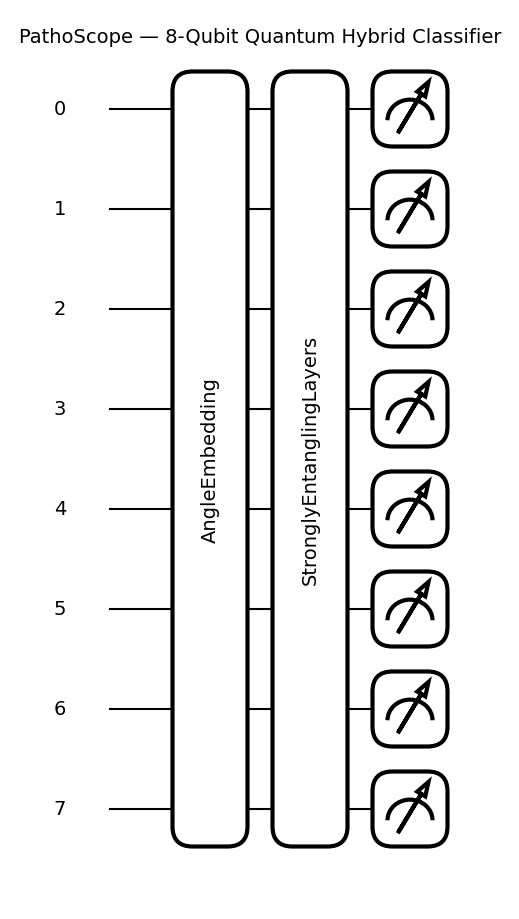


Circuit figure saved:
/content/drive/MyDrive/PathoScope/data/notebook_06_results/fig_06_circuit.png


In [28]:
import matplotlib.pyplot as plt
import pennylane as qml

# Use a fixed set of example inputs and trained quantum weights
example_input_06 = X_train_angle_q_06[0]

def circuit_for_plot_06(inputs):
    qml.AngleEmbedding(
        inputs,
        wires=range(8),
        rotation="Y"
    )

    qml.StronglyEntanglingLayers(
        quantum_model_06.quantum_weights.detach(),
        wires=range(8)
    )

    return [
        qml.expval(qml.PauliZ(i))
        for i in range(8)
    ]

fig, ax = qml.draw_mpl(
    circuit_for_plot_06,
    decimals=2
)(example_input_06)

fig.suptitle(
    "PathoScope — 8-Qubit Quantum Hybrid Classifier",
    fontsize=14
)

fig.tight_layout()

circuit_path_06 = (
    results_dir_06 / "fig_06_circuit.png"
)

fig.savefig(
    circuit_path_06,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nCircuit figure saved:")
print(circuit_path_06)

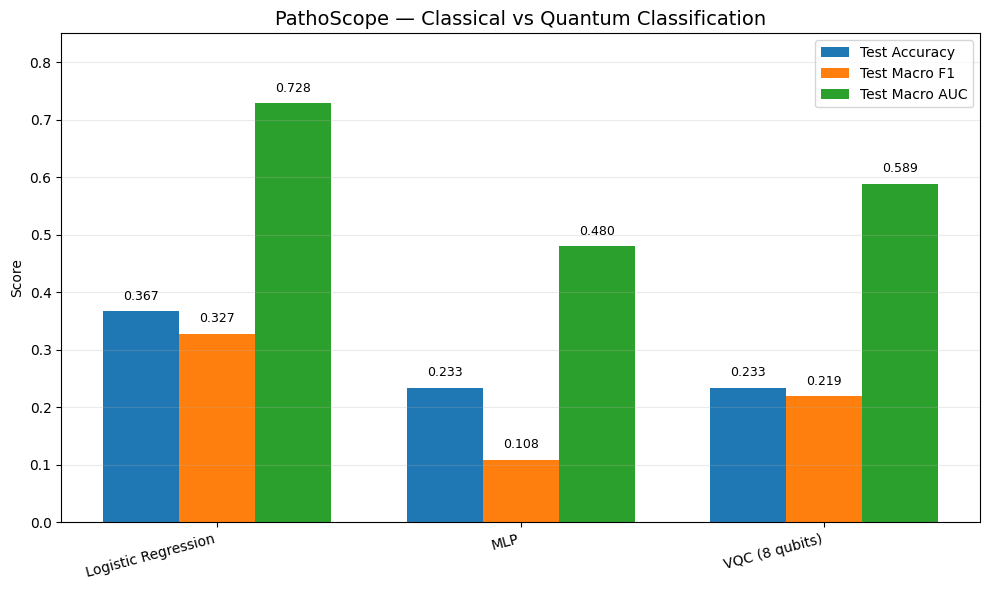


Comparison figure saved:
/content/drive/MyDrive/PathoScope/data/notebook_06_results/fig_06_quantum_vs_classical.png


In [29]:
import matplotlib.pyplot as plt
import numpy as np

models_06 = final_results_06["Model"].tolist()

metrics_06 = [
    "Test Accuracy",
    "Test Macro F1",
    "Test Macro AUC"
]

x_06 = np.arange(len(models_06))
width_06 = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics_06):

    values_06 = final_results_06[metric].values

    ax.bar(
        x_06 + (i - 1) * width_06,
        values_06,
        width_06,
        label=metric
    )

    for j, value in enumerate(values_06):
        ax.text(
            x_06[j] + (i - 1) * width_06,
            value + 0.015,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    "PathoScope — Classical vs Quantum Classification",
    fontsize=14
)

ax.set_ylabel("Score")
ax.set_ylim(0, 0.85)

ax.set_xticks(x_06)
ax.set_xticklabels(
    models_06,
    rotation=15,
    ha="right"
)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.25
)

fig.tight_layout()

comparison_fig_path_06 = (
    results_dir_06 / "fig_06_quantum_vs_classical.png"
)

fig.savefig(
    comparison_fig_path_06,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nComparison figure saved:")
print(comparison_fig_path_06)


In [30]:
import joblib
import numpy as np

# Save PCA and preprocessing objects
joblib.dump(
    pca_06,
    results_dir_06 / "pca_8_components.joblib"
)

joblib.dump(
    scaler_06,
    results_dir_06 / "feature_standard_scaler.joblib"
)

joblib.dump(
    angle_scaler_06,
    results_dir_06 / "angle_scaler.joblib"
)

# Save slide split indices
np.save(
    results_dir_06 / "train_indices.npy",
    train_idx_06
)

np.save(
    results_dir_06 / "validation_indices.npy",
    val_idx_06
)

np.save(
    results_dir_06 / "test_indices.npy",
    test_idx_06
)

# Save configuration
config_06 = {
    "feature_source": "EfficientNet-B0 1280-D tile features, mean pooled per slide",
    "pca_components": 8,
    "train_slides": 140,
    "validation_slides": 30,
    "test_slides": 30,
    "random_state": 42,
    "n_qubits": 8,
    "quantum_layers": 3,
    "angle_encoding": "Y",
    "quantum_parameters": 72,
    "linear_head_parameters": 54,
    "total_trainable_parameters": 126,
    "best_vqc_epoch": int(best_epoch_q_06),
    "vqc_test_accuracy": float(vqc_test_acc_06),
    "vqc_test_macro_f1": float(vqc_test_f1_06),
    "vqc_test_macro_auc": float(vqc_test_auc_06)
}

config_df_06 = pd.DataFrame(
    list(config_06.items()),
    columns=["Parameter", "Value"]
)

config_df_06.to_csv(
    results_dir_06 / "experiment_configuration.csv",
    index=False
)

print("Reproducibility artifacts saved.")
print()
print("Notebook 06 directory:")
print(results_dir_06)
print()
print("Files:")
for file in sorted(results_dir_06.iterdir()):
    print(file.name)


Reproducibility artifacts saved.

Notebook 06 directory:
/content/drive/MyDrive/PathoScope/data/notebook_06_results

Files:
angle_scaler.joblib
experiment_configuration.csv
feature_standard_scaler.joblib
fig_06_circuit.png
fig_06_quantum_vs_classical.png
pca_8_components.joblib
quantum_vs_classical_results.csv
test_indices.npy
train_indices.npy
validation_indices.npy
vqc_classification_report.csv
vqc_hybrid_classifier.pth
vqc_training_history.csv


In [31]:
from pathlib import Path
import os

base_07 = Path(
    "/content/drive/MyDrive/PathoScope/data"
)

print("PathoScope data directory:")
print(base_07)

print("\nAvailable folders:")
for item in sorted(base_07.iterdir()):
    if item.is_dir():
        print("DIR :", item.name)

print("\nImportant files:")
for item in sorted(base_07.rglob("*")):
    if item.is_file():
        name = item.name.lower()

        if (
            "deeplab" in name
            or "unet" in name
            or "mil" in name
            or "tiles.csv" in name
            or name.endswith(".pth")
        ):
            print(item)

PathoScope data directory:
/content/drive/MyDrive/PathoScope/data

Available folders:
DIR : notebook_03_results
DIR : notebook_04_results
DIR : notebook_05_results
DIR : notebook_06_results
DIR : notebook_07_results

Important files:
/content/drive/MyDrive/PathoScope/data/notebook_03_results/tile_clf.pth
/content/drive/MyDrive/PathoScope/data/notebook_03_results/tile_clf_densenet121.pth
/content/drive/MyDrive/PathoScope/data/notebook_04_results/deeplabv3plus_resnet34.pth
/content/drive/MyDrive/PathoScope/data/notebook_04_results/unet.pth
/content/drive/MyDrive/PathoScope/data/notebook_04_results/unet_resnet50.pth
/content/drive/MyDrive/PathoScope/data/notebook_04_results/unetpp_resnet34.pth
/content/drive/MyDrive/PathoScope/data/notebook_05_results/combined_attention_mil.pth
/content/drive/MyDrive/PathoScope/data/notebook_05_results/ordinal_attention_mil_classification_report.csv
/content/drive/MyDrive/PathoScope/data/notebook_05_results/ordinal_attention_mil_confusion_matrix.csv
/cont

In [32]:
import torch
import numpy as np
from pathlib import Path

import segmentation_models_pytorch as smp

device_07 = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

seg_checkpoint_07 = Path(
    "/content/drive/MyDrive/PathoScope/data/"
    "notebook_04_results/deeplabv3plus_resnet34.pth"
)

checkpoint_07 = torch.load(
    seg_checkpoint_07,
    map_location=device_07
)

print("Checkpoint keys:")
print(list(checkpoint_07.keys()))

# Recreate the exact Notebook 04 architecture
seg_model_07 = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

# Load only the trained model weights
seg_model_07.load_state_dict(
    checkpoint_07["model_state_dict"]
)

seg_model_07 = seg_model_07.to(device_07)
seg_model_07.eval()

total_params_07 = sum(
    p.numel()
    for p in seg_model_07.parameters()
)

print("\nModel loaded successfully.")
print("Device:", device_07)
print("Architecture: DeepLabV3+")
print("Encoder: ResNet34")
print("Parameters:", f"{total_params_07:,}")

print("\nSaved checkpoint information:")
print("Epoch:", checkpoint_07.get("epoch"))
print("Validation Dice:", checkpoint_07.get("val_dice"))
print("Validation IoU:", checkpoint_07.get("val_iou"))

Checkpoint keys:
['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_dice', 'val_iou']

Model loaded successfully.
Device: cpu
Architecture: DeepLabV3+
Encoder: ResNet34
Parameters: 22,437,457

Saved checkpoint information:
Epoch: 10
Validation Dice: 0.8097462289036592
Validation IoU: 0.7952667223911762


In [33]:
from PIL import Image
import numpy as np
import torch

# Find the normalized tile directory from Notebook 06
norm_dir_07 = Path(
    "/content/pathoscope_06/tiles_norm"
)

if not norm_dir_07.exists():
    raise FileNotFoundError(
        f"Normalized tiles not found: {norm_dir_07}"
    )

# Select one tile
sample_tile_07 = sorted(
    norm_dir_07.glob("*.jpg")
)[0]

# Load RGB image
sample_image_07 = Image.open(
    sample_tile_07
).convert("RGB")

# Ensure 256 x 256
sample_image_07 = sample_image_07.resize(
    (256, 256)
)

# Same preprocessing used in Notebook 04
sample_array_07 = np.array(
    sample_image_07
)

sample_tensor_07 = torch.from_numpy(
    sample_array_07
).permute(2, 0, 1).float() / 255.0

sample_tensor_07 = sample_tensor_07.unsqueeze(
    0
).to(device_07)

# Inference
with torch.no_grad():
    sample_logits_07 = seg_model_07(
        sample_tensor_07
    )

sample_probability_07 = torch.sigmoid(
    sample_logits_07
)

print("Sample tile:", sample_tile_07.name)
print("Input shape:", sample_tensor_07.shape)
print("Input range:",
      sample_tensor_07.min().item(),
      "to",
      sample_tensor_07.max().item())

print("\nOutput shape:", sample_logits_07.shape)

print("Logit range:",
      sample_logits_07.min().item(),
      "to",
      sample_logits_07.max().item())

print("\nProbability range:",
      sample_probability_07.min().item(),
      "to",
      sample_probability_07.max().item())

print(
    "\nPredicted tumor area @ 0.50:",
    (sample_probability_07 >= 0.50)
    .float()
    .mean()
    .item()
)

Sample tile: 008069b542b0439ed69b194674051964_x10240_y2048.jpg
Input shape: torch.Size([1, 3, 256, 256])
Input range: 0.01568627543747425 to 1.0

Output shape: torch.Size([1, 1, 256, 256])
Logit range: -15.895913124084473 to -5.535750865936279

Probability range: 1.2487991796206188e-07 to 0.003927758429199457

Predicted tumor area @ 0.50: 0.0


In [1]:
!pip -q install --upgrade --force-reinstall \
    "protobuf==6.31.1" \
    "onnx==1.18.0" \
    "onnxscript" \
    "onnxruntime"

print("Package repair completed.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.
Package repair completed.


In [2]:
!pip uninstall -y onnx onnxscript onnxruntime

!pip install --no-cache-dir \
    "onnx==1.18.0" \
    "onnxscript==0.3.2" \
    "onnxruntime==1.22.0"

print("ONNX packages reinstalled.")

Found existing installation: onnx 1.18.0
Uninstalling onnx-1.18.0:
  Successfully uninstalled onnx-1.18.0
Found existing installation: onnxscript 0.7.2
Uninstalling onnxscript-0.7.2:
  Successfully uninstalled onnxscript-0.7.2
Found existing installation: onnxruntime 1.30.0
Uninstalling onnxruntime-1.30.0:
  Successfully uninstalled onnxruntime-1.30.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 143.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.4/667.4 kB 172.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 115.7 MB/s eta 0:00:00
ONNX packages reinstalled.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

base_07 = Path("/content/drive/MyDrive/PathoScope/data")

checkpoint_07 = (
    base_07
    / "notebook_04_results"
    / "deeplabv3plus_resnet34.pth"
)

tiles_norm_07 = Path("/content/pathoscope_06/tiles_norm")

print("Checkpoint exists:", checkpoint_07.exists())
print("Checkpoint:", checkpoint_07)

print("tiles_norm exists:", tiles_norm_07.exists())

if checkpoint_07.exists():
    print(
        "Checkpoint size:",
        f"{checkpoint_07.stat().st_size / (1024**2):.2f} MB"
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint exists: True
Checkpoint: /content/drive/MyDrive/PathoScope/data/notebook_04_results/deeplabv3plus_resnet34.pth
tiles_norm exists: True
Checkpoint size: 257.07 MB


In [2]:
!pip -q install segmentation-models-pytorch==0.5.0

import torch
import segmentation_models_pytorch as smp

device_07 = torch.device("cpu")

seg_model_07 = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

checkpoint_data_07 = torch.load(
    checkpoint_07,
    map_location=device_07
)

seg_model_07.load_state_dict(
    checkpoint_data_07["model_state_dict"]
)

seg_model_07 = seg_model_07.to(device_07)
seg_model_07.eval()

print("Model loaded successfully.")
print("Device:", device_07)
print("Architecture: DeepLabV3+")
print("Encoder: ResNet34")
print(
    "Parameters:",
    f"{sum(p.numel() for p in seg_model_07.parameters()):,}"
)
print("Saved epoch:", checkpoint_data_07["epoch"])
print("Validation Dice:", checkpoint_data_07["val_dice"])
print("Validation IoU:", checkpoint_data_07["val_iou"])

Model loaded successfully.
Device: cpu
Architecture: DeepLabV3+
Encoder: ResNet34
Parameters: 22,437,457
Saved epoch: 10
Validation Dice: 0.8097462289036592
Validation IoU: 0.7952667223911762


In [3]:
import onnx
import onnxscript
import onnxruntime as ort

print("ONNX:", onnx.__version__)
print("ONNXScript:", onnxscript.__version__)
print("ONNX Runtime:", ort.__version__)

print("\nONNX environment is working.")

ONNX: 1.18.0
ONNXScript: 0.3.2
ONNX Runtime: 1.22.0

ONNX environment is working.


In [5]:
!pip -q install --upgrade "onnxscript>=0.5.0"

import onnxscript

print("ONNXScript version:", onnxscript.__version__)

ONNXScript version: 0.3.2


In [6]:
!pip uninstall -y onnxscript

!pip install --no-cache-dir --upgrade onnxscript

print("\nInstallation finished.")

Found existing installation: onnxscript 0.7.2
Uninstalling onnxscript-0.7.2:
  Successfully uninstalled onnxscript-0.7.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 16.9 MB/s eta 0:00:00



Installation finished.


In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import torch
import onnx
import onnxscript
import onnxruntime as ort

print("PyTorch:", torch.__version__)
print("ONNX:", onnx.__version__)
print("ONNXScript:", onnxscript.__version__)
print("ONNX Runtime:", ort.__version__)

print("\nONNX environment is ready.")

PyTorch: 2.11.0+cpu
ONNX: 1.18.0
ONNXScript: 0.7.2
ONNX Runtime: 1.22.0

ONNX environment is ready.


In [2]:
from pathlib import Path
import torch

# Reload the model after the runtime restart
import segmentation_models_pytorch as smp

base_07 = Path("/content/drive/MyDrive/PathoScope/data")

checkpoint_07 = (
    base_07
    / "notebook_04_results"
    / "deeplabv3plus_resnet34.pth"
)

onnx_path_07 = (
    base_07
    / "notebook_07_results"
    / "deeplabv3plus_resnet34.onnx"
)

onnx_path_07.parent.mkdir(
    parents=True,
    exist_ok=True
)

device_07 = torch.device("cpu")

seg_model_07 = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

checkpoint_data_07 = torch.load(
    checkpoint_07,
    map_location=device_07
)

seg_model_07.load_state_dict(
    checkpoint_data_07["model_state_dict"]
)

seg_model_07 = seg_model_07.to(device_07)
seg_model_07.eval()

dummy_input_07 = torch.randn(
    1,
    3,
    256,
    256,
    dtype=torch.float32
)

print("Starting ONNX export with opset 18...")

torch.onnx.export(
    seg_model_07,
    dummy_input_07,
    str(onnx_path_07),
    export_params=True,
    opset_version=18,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch"},
        "output": {0: "batch"}
    }
)

print("\nONNX export completed.")
print("File:", onnx_path_07)
print("Exists:", onnx_path_07.exists())

if onnx_path_07.exists():
    print(
        "Size:",
        f"{onnx_path_07.stat().st_size / (1024**2):.2f} MB"
    )

Starting ONNX export with opset 18...


/tmp/ipykernel_34145/2016297687.py:57: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `DeepLabV3Plus([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DeepLabV3Plus([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅

ONNX export completed.
File: /content/drive/MyDrive/PathoScope/data/notebook_07_results/deeplabv3plus_resnet34.onnx
Exists: True
Size: 0.27 MB


In [3]:
import numpy as np
import torch
import onnx
import onnxruntime as ort
from PIL import Image

# Use the same real normalized tile used earlier
sample_tile_07 = (
    Path("/content/pathoscope_06/tiles_norm")
    / "008069b542b0439ed69b194674051964_x10240_y2048.jpg"
)

# Load and preprocess exactly as Notebook 04
img_07 = Image.open(sample_tile_07).convert("RGB")
img_07 = img_07.resize((256, 256))

x_07 = (
    torch.from_numpy(np.array(img_07))
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    / 255.0
)

# PyTorch output
with torch.no_grad():
    pytorch_output_07 = seg_model_07(x_07)

pytorch_output_np_07 = (
    pytorch_output_07.cpu()
    .numpy()
    .astype(np.float32)
)

# Load ONNX model
onnx_session_07 = ort.InferenceSession(
    str(onnx_path_07),
    providers=["CPUExecutionProvider"]
)

onnx_output_07 = onnx_session_07.run(
    ["output"],
    {"input": x_07.numpy().astype(np.float32)}
)[0]

# Compare
difference_07 = np.abs(
    pytorch_output_np_07 - onnx_output_07
)

print("PyTorch output shape:", pytorch_output_np_07.shape)
print("ONNX output shape:", onnx_output_07.shape)

print()
print("PyTorch logit range:")
print(
    float(pytorch_output_np_07.min()),
    "to",
    float(pytorch_output_np_07.max())
)

print("ONNX logit range:")
print(
    float(onnx_output_07.min()),
    "to",
    float(onnx_output_07.max())
)

print()
print("Maximum absolute difference:", float(difference_07.max()))
print("Mean absolute difference:", float(difference_07.mean()))

print()
print("ONNX validation completed.")

PyTorch output shape: (1, 1, 256, 256)
ONNX output shape: (1, 1, 256, 256)

PyTorch logit range:
-15.895913124084473 to -5.535750865936279
ONNX logit range:
-15.895909309387207 to -5.53574800491333

Maximum absolute difference: 2.002716064453125e-05
Mean absolute difference: 6.0487218433991075e-06

ONNX validation completed.


In [4]:
import time
import numpy as np
import torch

# Warm-up
with torch.no_grad():
    for _ in range(5):
        _ = seg_model_07(x_07)

for _ in range(5):
    _ = onnx_session_07.run(
        ["output"],
        {"input": x_07.numpy().astype(np.float32)}
    )

# PyTorch benchmark
pytorch_times_07 = []

with torch.no_grad():
    for _ in range(20):
        start = time.perf_counter()

        _ = seg_model_07(x_07)

        end = time.perf_counter()
        pytorch_times_07.append(end - start)

# ONNX Runtime benchmark
onnx_times_07 = []

x_numpy_07 = x_07.numpy().astype(np.float32)

for _ in range(20):
    start = time.perf_counter()

    _ = onnx_session_07.run(
        ["output"],
        {"input": x_numpy_07}
    )

    end = time.perf_counter()
    onnx_times_07.append(end - start)

# Convert to milliseconds
pytorch_ms_07 = np.array(pytorch_times_07) * 1000
onnx_ms_07 = np.array(onnx_times_07) * 1000

pytorch_mean_07 = pytorch_ms_07.mean()
onnx_mean_07 = onnx_ms_07.mean()

speedup_07 = pytorch_mean_07 / onnx_mean_07

print("CPU inference benchmark")
print()
print(
    "PyTorch mean:",
    f"{pytorch_mean_07:.2f} ms"
)
print(
    "PyTorch median:",
    f"{np.median(pytorch_ms_07):.2f} ms"
)

print()
print(
    "ONNX Runtime mean:",
    f"{onnx_mean_07:.2f} ms"
)
print(
    "ONNX Runtime median:",
    f"{np.median(onnx_ms_07):.2f} ms"
)

print()
print(
    "ONNX Runtime / PyTorch speed ratio:",
    f"{speedup_07:.2f}x"
)

CPU inference benchmark

PyTorch mean: 1241.02 ms
PyTorch median: 1158.93 ms

ONNX Runtime mean: 633.95 ms
ONNX Runtime median: 503.25 ms

ONNX Runtime / PyTorch speed ratio: 1.96x


In [5]:
import pandas as pd
from pathlib import Path

benchmark_07 = pd.DataFrame([
    {
        "model": "DeepLabV3Plus_ResNet34",
        "input_size": "1x3x256x256",
        "device": "CPU",
        "pytorch_mean_ms": pytorch_mean_07,
        "pytorch_median_ms": float(np.median(pytorch_ms_07)),
        "onnxruntime_mean_ms": onnx_mean_07,
        "onnxruntime_median_ms": float(np.median(onnx_ms_07)),
        "onnx_speed_ratio": speedup_07,
        "max_absolute_difference": float(difference_07.max()),
        "mean_absolute_difference": float(difference_07.mean())
    }
])

benchmark_path_07 = (
    Path("/content/drive/MyDrive/PathoScope/data/")
    / "notebook_07_results"
    / "onnx_benchmark.csv"
)

benchmark_07.to_csv(
    benchmark_path_07,
    index=False
)

print(benchmark_07.to_string(index=False))
print()
print("Saved:", benchmark_path_07)

                 model  input_size device  pytorch_mean_ms  pytorch_median_ms  onnxruntime_mean_ms  onnxruntime_median_ms  onnx_speed_ratio  max_absolute_difference  mean_absolute_difference
DeepLabV3Plus_ResNet34 1x3x256x256    CPU      1241.018962         1158.93218            633.95046             503.246572          1.957596                  0.00002                  0.000006

Saved: /content/drive/MyDrive/PathoScope/data/notebook_07_results/onnx_benchmark.csv


In [6]:
from pathlib import Path

mil_checkpoint_07 = (
    Path("/content/drive/MyDrive/PathoScope/data/")
    / "notebook_05_results"
    / "combined_attention_mil.pth"
)

print("Combined MIL checkpoint exists:", mil_checkpoint_07.exists())
print("Path:", mil_checkpoint_07)

if mil_checkpoint_07.exists():
    print(
        "Size:",
        f"{mil_checkpoint_07.stat().st_size / (1024**2):.2f} MB"
    )

Combined MIL checkpoint exists: True
Path: /content/drive/MyDrive/PathoScope/data/notebook_05_results/combined_attention_mil.pth
Size: 1.51 MB


In [8]:
import torch

mil_checkpoint_data_07 = torch.load(
    mil_checkpoint_07,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint type:", type(mil_checkpoint_data_07))

if isinstance(mil_checkpoint_data_07, dict):
    print("\nCheckpoint keys:")
    for key in mil_checkpoint_data_07.keys():
        print("-", key)

    print("\nCheckpoint contents:")
    for key, value in mil_checkpoint_data_07.items():
        if torch.is_tensor(value):
            print(f"{key}: tensor {tuple(value.shape)}")
        elif isinstance(value, (int, float, str)):
            print(f"{key}: {value}")
        else:
            print(f"{key}: {type(value)}")

Checkpoint type: <class 'dict'>

Checkpoint keys:
- model_state_dict
- best_epoch
- best_val_qwk
- input_dim
- hidden_dim
- num_classes

Checkpoint contents:
model_state_dict: <class 'collections.OrderedDict'>
best_epoch: 27
best_val_qwk: 0.5924170616113744
input_dim: 1284
hidden_dim: 256
num_classes: 6


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CombinedAttentionMIL07(nn.Module):
    def __init__(
        self,
        input_dim=1284,
        hidden_dim=256,
        num_classes=6
    ):
        super().__init__()

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_attention=False):

        h = self.feature_projection(x)

        attention_logits = self.attention(h)

        attention_weights = F.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * h,
            dim=1
        )

        logits = self.classifier(
            slide_representation
        )

        if return_attention:
            return (
                logits,
                attention_weights.squeeze(-1)
            )

        return logits


combined_mil_07 = CombinedAttentionMIL07(
    input_dim=mil_checkpoint_data_07["input_dim"],
    hidden_dim=mil_checkpoint_data_07["hidden_dim"],
    num_classes=mil_checkpoint_data_07["num_classes"]
)

combined_mil_07.load_state_dict(
    mil_checkpoint_data_07["model_state_dict"]
)

combined_mil_07.eval()

print("Combined Attention-MIL loaded successfully.")

print(
    "Parameters:",
    f"{sum(p.numel() for p in combined_mil_07.parameters()):,}"
)

print("Input dimension:", mil_checkpoint_data_07["input_dim"])
print("Hidden dimension:", mil_checkpoint_data_07["hidden_dim"])
print("Number of classes:", mil_checkpoint_data_07["num_classes"])
print("Best validation QWK:", mil_checkpoint_data_07["best_val_qwk"])

Combined Attention-MIL loaded successfully.
Parameters: 395,655
Input dimension: 1284
Hidden dimension: 256
Number of classes: 6
Best validation QWK: 0.5924170616113744


In [13]:
import pandas as pd
from pathlib import Path

tiles_csv_07 = (
    Path("/content/drive/MyDrive/PathoScope/data")
    / "tiles.csv"
)

tiles_df_07 = pd.read_csv(tiles_csv_07)

slide_counts_07 = (
    tiles_df_07
    .groupby("image_id")
    .size()
)

valid_slides_07 = slide_counts_07[
    slide_counts_07 == 64
].index.tolist()

sample_slide_07 = valid_slides_07[0]

sample_slide_df_07 = (
    tiles_df_07[
        tiles_df_07["image_id"] == sample_slide_07
    ]
    .sort_values(["y", "x"])
    .reset_index(drop=True)
)

print("Total slides:", tiles_df_07["image_id"].nunique())
print("Slides with exactly 64 tiles:", len(valid_slides_07))

print()
print("Selected slide:", sample_slide_07)
print("Number of tiles:", len(sample_slide_df_07))
print(
    "True ISUP grade:",
    int(sample_slide_df_07["isup_grade"].iloc[0])
)

print()
print("Tile coordinate range:")
print(
    "X:",
    int(sample_slide_df_07["x"].min()),
    "to",
    int(sample_slide_df_07["x"].max())
)
print(
    "Y:",
    int(sample_slide_df_07["y"].min()),
    "to",
    int(sample_slide_df_07["y"].max())
)

Total slides: 200
Slides with exactly 64 tiles: 200

Selected slide: 008069b542b0439ed69b194674051964
Number of tiles: 64
True ISUP grade: 4

Tile coordinate range:
X: 1280 to 20992
Y: 768 to 7680


In [14]:
import torch
from pathlib import Path

# Load the saved EfficientNet features from Notebook 05
features_path_07 = (
    Path("/content/pathoscope_05")
    / "tile_features.pt"
)

print("Feature file exists:", features_path_07.exists())
print("Path:", features_path_07)

if features_path_07.exists():
    all_features_07 = torch.load(
        features_path_07,
        map_location="cpu",
        weights_only=False
    )

    print(
        "All features shape:",
        tuple(all_features_07.shape)
    )

Feature file exists: False
Path: /content/pathoscope_05/tile_features.pt


In [15]:
import torch
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from pathlib import Path

device_07 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Same normalized-tile directory used in Notebook 05
NORM_DIR_07 = Path("/content/pathoscope_05/tiles_norm")

# If the directory was lost after restart, extract it again
if not NORM_DIR_07.exists():
    import zipfile

    norm_zip_07 = (
        Path("/content/drive/MyDrive/PathoScope/data")
        / "tiles_norm.zip"
    )

    print("Extracting normalized tiles...")
    NORM_DIR_07.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(norm_zip_07, "r") as z:
        z.extractall(NORM_DIR_07)

    print("Extraction complete.")

print("Normalized tile directory:", NORM_DIR_07)
print("Device:", device_07)

# Match each CSV tile to its normalized JPEG
sample_slide_df_07["norm_path"] = sample_slide_df_07.apply(
    lambda row: NORM_DIR_07 / Path(row["image_path"]).name,
    axis=1
)

missing_07 = [
    str(p)
    for p in sample_slide_df_07["norm_path"]
    if not p.exists()
]

print("Selected slide tiles:", len(sample_slide_df_07))
print("Missing normalized tiles:", len(missing_07))

if missing_07:
    print("First missing file:", missing_07[0])
    raise FileNotFoundError("One or more normalized tiles are missing.")

# Notebook 05 used the ImageNet preprocessing associated with EfficientNet-B0.
weights_07 = EfficientNet_B0_Weights.DEFAULT
preprocess_07 = weights_07.transforms()

encoder_07 = efficientnet_b0(weights=weights_07)

# Remove the final classifier so the output is the 1280-D CNN representation.
encoder_07.classifier = torch.nn.Identity()
encoder_07 = encoder_07.to(device_07)
encoder_07.eval()

features_07 = []

with torch.no_grad():
    for _, row in sample_slide_df_07.iterrows():
        image = Image.open(row["norm_path"]).convert("RGB")
        image_tensor = preprocess_07(image).unsqueeze(0).to(device_07)

        feature = encoder_07(image_tensor)
        features_07.append(feature.cpu())

slide_cnn_features_07 = torch.cat(features_07, dim=0)

print()
print("CNN feature shape:", tuple(slide_cnn_features_07.shape))
print("Expected:", (64, 1280))
print("Feature dtype:", slide_cnn_features_07.dtype)
print("Feature min:", slide_cnn_features_07.min().item())
print("Feature max:", slide_cnn_features_07.max().item())

Extracting normalized tiles...
Extraction complete.
Normalized tile directory: /content/pathoscope_05/tiles_norm
Device: cpu
Selected slide tiles: 64
Missing normalized tiles: 0

CNN feature shape: (64, 1280)
Expected: (64, 1280)
Feature dtype: torch.float32
Feature min: -0.26503050327301025
Feature max: 5.222174644470215


In [16]:
import numpy as np
import onnxruntime as ort
from PIL import Image

# Exact ONNX model exported and validated in Notebook 07
onnx_path_07 = (
    "/content/drive/MyDrive/PathoScope/data/"
    "notebook_07_results/deeplabv3plus_resnet34.onnx"
)

session_07 = ort.InferenceSession(
    onnx_path_07,
    providers=["CPUExecutionProvider"]
)

input_name_07 = session_07.get_inputs()[0].name
output_name_07 = session_07.get_outputs()[0].name

print("ONNX input:", input_name_07)
print("ONNX output:", output_name_07)

seg_features_07 = []
seg_probability_maps_07 = []

for _, row in sample_slide_df_07.iterrows():

    image = Image.open(row["norm_path"]).convert("RGB")
    image = image.resize((256, 256))

    image_np = np.asarray(image, dtype=np.float32) / 255.0
    input_np = np.transpose(image_np, (2, 0, 1))[None, ...]

    logits = session_07.run(
        [output_name_07],
        {input_name_07: input_np}
    )[0]

    # Sigmoid converts logits to tumor probabilities
    probability = 1.0 / (1.0 + np.exp(-logits[0, 0]))

    mean_probability = float(probability.mean())
    max_probability = float(probability.max())
    area_01 = float((probability >= 0.10).mean())
    area_05 = float((probability >= 0.50).mean())

    seg_features_07.append([
        mean_probability,
        max_probability,
        area_01,
        area_05
    ])

    seg_probability_maps_07.append(probability)

seg_features_07 = np.asarray(
    seg_features_07,
    dtype=np.float32
)

seg_probability_maps_07 = np.asarray(
    seg_probability_maps_07,
    dtype=np.float32
)

print()
print("Segmentation feature shape:", seg_features_07.shape)
print("Expected:", (64, 4))

print()
print("Feature columns:")
print([
    "mean_probability",
    "max_probability",
    "area_01",
    "area_05"
])

print()
print("Feature summary:")
print("Mean probability:", seg_features_07[:, 0].mean())
print("Max probability:", seg_features_07[:, 1].max())
print("Mean area @ 0.10:", seg_features_07[:, 2].mean())
print("Mean area @ 0.50:", seg_features_07[:, 3].mean())

print()
print("Probability map shape:", seg_probability_maps_07.shape)

ONNX input: input
ONNX output: output

Segmentation feature shape: (64, 4)
Expected: (64, 4)

Feature columns:
['mean_probability', 'max_probability', 'area_01', 'area_05']

Feature summary:
Mean probability: 6.7786255e-05
Max probability: 0.02821456
Mean area @ 0.10: 0.0
Mean area @ 0.50: 0.0

Probability map shape: (64, 256, 256)


In [17]:
import torch
from pathlib import Path

# Combine:
# EfficientNet-B0: 1280 features
# DeepLab: 4 segmentation features

seg_features_tensor_07 = torch.from_numpy(
    seg_features_07
)

slide_features_07 = torch.cat(
    [
        slide_cnn_features_07,
        seg_features_tensor_07
    ],
    dim=1
)

print("Combined feature shape:", tuple(slide_features_07.shape))
print("Expected:", (64, 1284))
print("Combined dtype:", slide_features_07.dtype)

# Exact combined Attention-MIL architecture used in Notebook 05
class CombinedAttentionMIL_07(torch.nn.Module):

    def __init__(
        self,
        input_dim=1284,
        hidden_dim=256,
        num_classes=6
    ):
        super().__init__()

        self.feature_projection = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.25)
        )

        self.attention = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim, 128),
            torch.nn.Tanh(),
            torch.nn.Linear(128, 1)
        )

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.25),
            torch.nn.Linear(128, num_classes)
        )

    def forward(self, x, return_attention=False):

        h = self.feature_projection(x)

        attention_scores = self.attention(h)
        attention_weights = torch.softmax(
            attention_scores,
            dim=1
        )

        bag_representation = (
            attention_weights * h
        ).sum(dim=1)

        logits = self.classifier(
            bag_representation
        )

        if return_attention:
            return logits, attention_weights.squeeze(-1)

        return logits


mil_path_07 = (
    Path("/content/drive/MyDrive/PathoScope/data")
    / "notebook_05_results"
    / "combined_attention_mil.pth"
)

print()
print("MIL checkpoint exists:", mil_path_07.exists())
print("Checkpoint:", mil_path_07)

checkpoint_mil_07 = torch.load(
    mil_path_07,
    map_location="cpu",
    weights_only=False
)

mil_model_07 = CombinedAttentionMIL_07(
    input_dim=checkpoint_mil_07["input_dim"],
    hidden_dim=checkpoint_mil_07["hidden_dim"],
    num_classes=checkpoint_mil_07["num_classes"]
)

mil_model_07.load_state_dict(
    checkpoint_mil_07["model_state_dict"]
)

mil_model_07.eval()

print()
print("MIL input dimension:", checkpoint_mil_07["input_dim"])
print("MIL hidden dimension:", checkpoint_mil_07["hidden_dim"])
print("MIL classes:", checkpoint_mil_07["num_classes"])
print("Best validation QWK:", checkpoint_mil_07["best_val_qwk"])
print("Best epoch:", checkpoint_mil_07["best_epoch"])
print(
    "Model parameters:",
    sum(p.numel() for p in mil_model_07.parameters())
)

Combined feature shape: (64, 1284)
Expected: (64, 1284)
Combined dtype: torch.float32

MIL checkpoint exists: True
Checkpoint: /content/drive/MyDrive/PathoScope/data/notebook_05_results/combined_attention_mil.pth

MIL input dimension: 1284
MIL hidden dimension: 256
MIL classes: 6
Best validation QWK: 0.5924170616113744
Best epoch: 27
Model parameters: 395655


In [18]:
import numpy as np
import torch

# Add batch dimension: [64, 1284] -> [1, 64, 1284]
slide_input_07 = slide_features_07.unsqueeze(0)

with torch.no_grad():
    logits_07, attention_07 = mil_model_07(
        slide_input_07,
        return_attention=True
    )

probabilities_07 = torch.softmax(
    logits_07,
    dim=1
)

predicted_grade_07 = int(
    torch.argmax(probabilities_07, dim=1).item()
)

attention_07 = attention_07.squeeze(0).cpu().numpy()
probabilities_07 = probabilities_07.squeeze(0).cpu().numpy()
logits_07 = logits_07.squeeze(0).cpu().numpy()

# Normalize attention for easier interpretation
attention_07 = attention_07 / attention_07.sum()

print("Slide:", sample_slide_07)
print("True ISUP grade:", int(sample_slide_df_07["isup_grade"].iloc[0]))
print("Predicted ISUP grade:", predicted_grade_07)

print()
print("Class probabilities:")
for grade, probability in enumerate(probabilities_07):
    print(
        f"ISUP {grade}: {probability:.6f}"
    )

print()
print("Logits:")
print(logits_07)

print()
print("Attention shape:", attention_07.shape)
print("Attention sum:", attention_07.sum())
print("Maximum attention:", attention_07.max())
print("Minimum attention:", attention_07.min())

# Identify the 10 most attended tiles
top_attention_indices_07 = np.argsort(
    attention_07
)[::-1][:10]

top_attention_df_07 = sample_slide_df_07.iloc[
    top_attention_indices_07
][
    [
        "tile_id",
        "x",
        "y",
        "tile_label",
        "isup_grade"
    ]
].copy()

top_attention_df_07["attention"] = attention_07[
    top_attention_indices_07
]

top_attention_df_07 = top_attention_df_07.reset_index(
    drop=True
)

print()
print("Top 10 attended tiles:")
display(top_attention_df_07)

Slide: 008069b542b0439ed69b194674051964
True ISUP grade: 4
Predicted ISUP grade: 4

Class probabilities:
ISUP 0: 0.052819
ISUP 1: 0.091141
ISUP 2: 0.164750
ISUP 3: 0.187299
ISUP 4: 0.257091
ISUP 5: 0.246899

Logits:
[-0.8990448  -0.35350686  0.23851426  0.36678916  0.6835108   0.64306265]

Attention shape: (64,)
Attention sum: 1.0
Maximum attention: 0.1962183
Minimum attention: 0.00022596748

Top 10 attended tiles:


,tile_id,x,y,tile_label,isup_grade,attention
0,008069b542b0439ed69b194674051964_x12288_y2304,12288,2304,1,4,0.196218
1,008069b542b0439ed69b194674051964_x12544_y2048,12544,2048,1,4,0.179086
2,008069b542b0439ed69b194674051964_x12544_y2304,12544,2304,1,4,0.103234
3,008069b542b0439ed69b194674051964_x12544_y2560,12544,2560,1,4,0.045297
4,008069b542b0439ed69b194674051964_x17664_y1536,17664,1536,1,4,0.041280
5,008069b542b0439ed69b194674051964_x13824_y2560,13824,2560,1,4,0.029904
6,008069b542b0439ed69b194674051964_x8960_y3072,8960,3072,0,4,0.028464
7,008069b542b0439ed69b194674051964_x7168_y3840,7168,3840,0,4,0.025213
8,008069b542b0439ed69b194674051964_x17664_y2048,17664,2048,1,4,0.024862
9,008069b542b0439ed69b194674051964_x18944_y1280,18944,1280,0,4,0.023366


In [19]:
import numpy as np
import pandas as pd

# Copy the selected slide table
report_df_07 = sample_slide_df_07.copy()

# Add MIL attention
report_df_07["attention"] = attention_07

# Add segmentation-derived features
report_df_07["mean_probability"] = seg_features_07[:, 0]
report_df_07["max_probability"] = seg_features_07[:, 1]
report_df_07["area_01"] = seg_features_07[:, 2]
report_df_07["area_05"] = seg_features_07[:, 3]

# Sort spatially
report_df_07 = report_df_07.sort_values(
    ["y", "x"]
).reset_index(drop=True)

print("Report table shape:", report_df_07.shape)

print()
print("Spatial coordinate grid:")
print(
    "Unique X positions:",
    report_df_07["x"].nunique()
)
print(
    "Unique Y positions:",
    report_df_07["y"].nunique()
)

# Create coordinate lookup dictionaries
x_values_07 = sorted(report_df_07["x"].unique())
y_values_07 = sorted(report_df_07["y"].unique())

x_to_col_07 = {
    x: i for i, x in enumerate(x_values_07)
}

y_to_row_07 = {
    y: i for i, y in enumerate(y_values_07)
}

attention_map_07 = np.full(
    (len(y_values_07), len(x_values_07)),
    np.nan,
    dtype=np.float32
)

tumor_probability_map_07 = np.full(
    (len(y_values_07), len(x_values_07)),
    np.nan,
    dtype=np.float32
)

for _, row in report_df_07.iterrows():

    r = y_to_row_07[row["y"]]
    c = x_to_col_07[row["x"]]

    attention_map_07[r, c] = row["attention"]

    tumor_probability_map_07[r, c] = row[
        "max_probability"
    ]

print()
print("Attention map shape:", attention_map_07.shape)
print("Tumor probability map shape:", tumor_probability_map_07.shape)

print()
print("Attention map:")
print(np.round(attention_map_07, 4))

print()
print("Maximum tumor-probability map:")
print(np.round(tumor_probability_map_07, 4))

Report table shape: (64, 19)

Spatial coordinate grid:
Unique X positions: 40
Unique Y positions: 16

Attention map shape: (16, 40)
Tumor probability map shape: (16, 40)

Attention map:
[[   nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
     nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
     nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
     nan    nan 0.0004    nan    nan    nan    nan    nan    nan    nan]
 [   nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
     nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
     nan    nan    nan    nan    nan    nan    nan    nan    nan 0.0012
     nan    nan    nan 0.0003    nan 0.0081    nan    nan    nan    nan]
 [   nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
     nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
     nan    nan    nan    nan    nan    nan    nan    nan    nan    nan
  0.003  0.0024    n

In [20]:
import cv2
import numpy as np
import pandas as pd

# Use the segmentation probability maps already generated
lesion_records_07 = []

for idx, probability in enumerate(seg_probability_maps_07):

    # Binary tumor mask at the 0.50 threshold
    binary_mask = (
        probability >= 0.50
    ).astype(np.uint8)

    # Connected components within this tile
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary_mask,
        connectivity=8
    )

    component_count = 0
    largest_component_area = 0

    for component_id in range(1, num_labels):
        area = int(
            stats[component_id, cv2.CC_STAT_AREA]
        )

        # Ignore extremely small isolated components
        if area >= 20:
            component_count += 1
            largest_component_area = max(
                largest_component_area,
                area
            )

    tile_area_fraction = float(
        binary_mask.mean()
    )

    lesion_records_07.append({
        "tile_index": idx,
        "tumor_area_fraction": tile_area_fraction,
        "lesion_count": component_count,
        "largest_lesion_pixels": largest_component_area
    })

lesion_df_07 = pd.DataFrame(
    lesion_records_07
)

# Merge with the spatial report
report_df_07 = report_df_07.merge(
    lesion_df_07,
    left_on=report_df_07.index,
    right_on="tile_index",
    how="left"
)

# Slide-level tile-bag quantification
total_tiles_07 = len(report_df_07)

tumor_area_percent_07 = (
    report_df_07["tumor_area_fraction"].mean()
    * 100
)

total_lesions_07 = int(
    report_df_07["lesion_count"].sum()
)

tiles_with_tumor_07 = int(
    (report_df_07["tumor_area_fraction"] > 0).sum()
)

max_tumor_area_tile_07 = float(
    report_df_07["tumor_area_fraction"].max()
    * 100
)

print("Tile-bag slide quantification")
print("--------------------------------")
print("Slide:", sample_slide_07)
print("Total tiles:", total_tiles_07)
print("Tiles with predicted tumor:", tiles_with_tumor_07)
print(
    "Predicted tumor area:",
    f"{tumor_area_percent_07:.6f}%"
)
print(
    "Total detected tile-level lesions:",
    total_lesions_07
)
print(
    "Maximum tumor area in one tile:",
    f"{max_tumor_area_tile_07:.6f}%"
)

print()
print("Segmentation thresholds:")
print("Tumor probability threshold: 0.50")
print("Minimum connected-component area: 20 pixels")

print()
print("Top tiles by predicted tumor area:")
display(
    report_df_07[
        [
            "tile_id",
            "x",
            "y",
            "attention",
            "max_probability",
            "tumor_area_fraction",
            "lesion_count"
        ]
    ]
    .sort_values(
        "tumor_area_fraction",
        ascending=False
    )
    .head(10)
)

Tile-bag slide quantification
--------------------------------
Slide: 008069b542b0439ed69b194674051964
Total tiles: 64
Tiles with predicted tumor: 0
Predicted tumor area: 0.000000%
Total detected tile-level lesions: 0
Maximum tumor area in one tile: 0.000000%

Segmentation thresholds:
Tumor probability threshold: 0.50
Minimum connected-component area: 20 pixels

Top tiles by predicted tumor area:


,tile_id,x,y,attention,max_probability,tumor_area_fraction,lesion_count
0,008069b542b0439ed69b194674051964_x18432_y768,18432,768,0.000369,0.003624,0.0,0
1,008069b542b0439ed69b194674051964_x17664_y1024,17664,1024,0.001151,0.002363,0.0,0
2,008069b542b0439ed69b194674051964_x18688_y1024,18688,1024,0.000314,0.012113,0.0,0
3,008069b542b0439ed69b194674051964_x19456_y1024,19456,1024,0.008106,0.005258,0.0,0
4,008069b542b0439ed69b194674051964_x17920_y1280,17920,1280,0.002987,0.003120,0.0,0
5,008069b542b0439ed69b194674051964_x18176_y1280,18176,1280,0.002368,0.007275,0.0,0
6,008069b542b0439ed69b194674051964_x18944_y1280,18944,1280,0.023366,0.004511,0.0,0
7,008069b542b0439ed69b194674051964_x19968_y1280,19968,1280,0.000416,0.002385,0.0,0
8,008069b542b0439ed69b194674051964_x20736_y1280,20736,1280,0.006730,0.006704,0.0,0
9,008069b542b0439ed69b194674051964_x14592_y1536,14592,1536,0.000697,0.003348,0.0,0


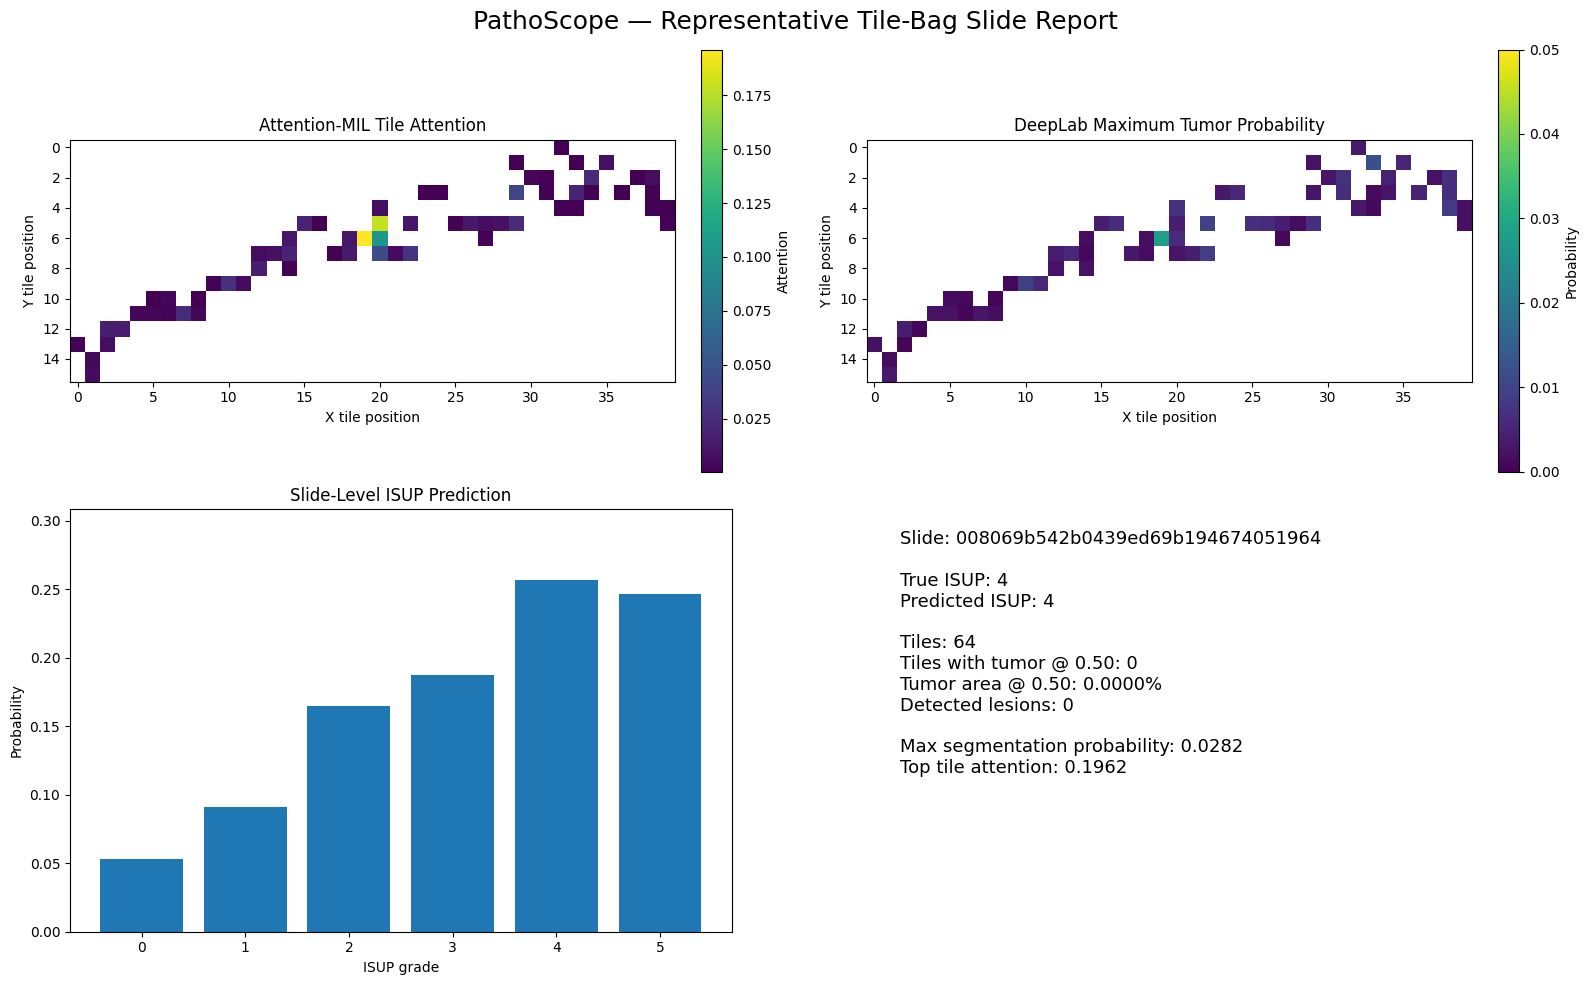


Report saved:
/content/drive/MyDrive/PathoScope/data/notebook_07_results/fig_07_slide_report.png
File exists: True


In [21]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

results_dir_07 = Path(
    "/content/drive/MyDrive/PathoScope/data/"
    "notebook_07_results"
)
results_dir_07.mkdir(
    parents=True,
    exist_ok=True
)

true_grade_07 = int(
    sample_slide_df_07["isup_grade"].iloc[0]
)

# Prepare maps for visualization
attention_display_07 = np.ma.masked_invalid(
    attention_map_07
)

tumor_display_07 = np.ma.masked_invalid(
    tumor_probability_map_07
)

fig = plt.figure(
    figsize=(16, 10)
)

# 1. Attention map
ax1 = plt.subplot(2, 2, 1)

im1 = ax1.imshow(
    attention_display_07,
    interpolation="nearest"
)

ax1.set_title(
    "Attention-MIL Tile Attention"
)
ax1.set_xlabel("X tile position")
ax1.set_ylabel("Y tile position")

plt.colorbar(
    im1,
    ax=ax1,
    fraction=0.046,
    pad=0.04,
    label="Attention"
)

# 2. Segmentation probability map
ax2 = plt.subplot(2, 2, 2)

im2 = ax2.imshow(
    tumor_display_07,
    interpolation="nearest",
    vmin=0,
    vmax=max(
        0.05,
        float(np.nanmax(tumor_probability_map_07))
    )
)

ax2.set_title(
    "DeepLab Maximum Tumor Probability"
)
ax2.set_xlabel("X tile position")
ax2.set_ylabel("Y tile position")

plt.colorbar(
    im2,
    ax=ax2,
    fraction=0.046,
    pad=0.04,
    label="Probability"
)

# 3. ISUP class probabilities
ax3 = plt.subplot(2, 2, 3)

grades_07 = np.arange(6)

ax3.bar(
    grades_07,
    probabilities_07
)

ax3.set_xticks(grades_07)
ax3.set_xlabel("ISUP grade")
ax3.set_ylabel("Probability")
ax3.set_title("Slide-Level ISUP Prediction")
ax3.set_ylim(
    0,
    max(0.30, float(probabilities_07.max()) * 1.2)
)

# 4. Summary
ax4 = plt.subplot(2, 2, 4)

ax4.axis("off")

summary_text_07 = (
    f"Slide: {sample_slide_07}\n\n"
    f"True ISUP: {true_grade_07}\n"
    f"Predicted ISUP: {predicted_grade_07}\n\n"
    f"Tiles: {total_tiles_07}\n"
    f"Tiles with tumor @ 0.50: "
    f"{tiles_with_tumor_07}\n"
    f"Tumor area @ 0.50: "
    f"{tumor_area_percent_07:.4f}%\n"
    f"Detected lesions: "
    f"{total_lesions_07}\n\n"
    f"Max segmentation probability: "
    f"{seg_features_07[:, 1].max():.4f}\n"
    f"Top tile attention: "
    f"{attention_07.max():.4f}"
)

ax4.text(
    0.05,
    0.95,
    summary_text_07,
    transform=ax4.transAxes,
    verticalalignment="top",
    fontsize=13
)

fig.suptitle(
    "PathoScope — Representative Tile-Bag Slide Report",
    fontsize=18
)

plt.tight_layout()

report_figure_path_07 = (
    results_dir_07
    / "fig_07_slide_report.png"
)

plt.savefig(
    report_figure_path_07,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print()
print("Report saved:")
print(report_figure_path_07)
print(
    "File exists:",
    report_figure_path_07.exists()
)

In [22]:
import pandas as pd
from pathlib import Path

results_dir_07 = Path(
    "/content/drive/MyDrive/PathoScope/data/"
    "notebook_07_results"
)

results_dir_07.mkdir(
    parents=True,
    exist_ok=True
)

# Create one-row slide-level result
slide_result_07 = {
    "image_id": sample_slide_07,
    "true_isup": true_grade_07,
    "predicted_isup": predicted_grade_07,
    "isup_0_probability": probabilities_07[0],
    "isup_1_probability": probabilities_07[1],
    "isup_2_probability": probabilities_07[2],
    "isup_3_probability": probabilities_07[3],
    "isup_4_probability": probabilities_07[4],
    "isup_5_probability": probabilities_07[5],
    "num_tiles": total_tiles_07,
    "tiles_with_tumor": tiles_with_tumor_07,
    "tumor_area_percent": tumor_area_percent_07,
    "lesion_count": total_lesions_07,
    "max_segmentation_probability": float(
        seg_features_07[:, 1].max()
    ),
    "max_tile_attention": float(
        attention_07.max()
    )
}

slide_results_df_07 = pd.DataFrame(
    [slide_result_07]
)

slide_results_path_07 = (
    results_dir_07 / "slide_results.csv"
)

slide_results_df_07.to_csv(
    slide_results_path_07,
    index=False
)

print("Notebook 07 final artifacts")
print("--------------------------------")
print(
    "ONNX model:",
    (
        results_dir_07
        / "deeplabv3plus_resnet34.onnx"
    ).exists()
)

print(
    "ONNX benchmark:",
    (
        results_dir_07
        / "onnx_benchmark.csv"
    ).exists()
)

print(
    "Slide report:",
    (
        results_dir_07
        / "fig_07_slide_report.png"
    ).exists()
)

print(
    "Slide results:",
    slide_results_path_07.exists()
)

print()
print("Final slide result:")
display(slide_results_df_07)

print()
print("Saved files:")

for path in sorted(results_dir_07.iterdir()):
    if path.is_file():
        print(
            f"{path.name:45s}"
            f"{path.stat().st_size / (1024 ** 2):8.2f} MB"
        )

print()
print("Notebook 07 validation:")
print("✓ 64-tile representative slide processed")
print("✓ EfficientNet-B0 1280-D features")
print("✓ DeepLabV3+ segmentation")
print("✓ 4 segmentation features")
print("✓ Combined 1284-D Attention-MIL")
print("✓ ISUP prediction")
print("✓ Attention map")
print("✓ Tumor probability map")
print("✓ Slide report generated")
print("✓ Results CSV saved")

Notebook 07 final artifacts
--------------------------------
ONNX model: True
ONNX benchmark: True
Slide report: True
Slide results: True

Final slide result:


,image_id,true_isup,predicted_isup,isup_0_probability,isup_1_probability,isup_2_probability,isup_3_probability,isup_4_probability,isup_5_probability,num_tiles,tiles_with_tumor,tumor_area_percent,lesion_count,max_segmentation_probability,max_tile_attention
0,008069b542b0439ed69b194674051964,4,4,0.052819,0.091141,0.16475,0.187299,0.257091,0.246899,64,0,0.0,0,0.028215,0.196218



Saved files:
deeplabv3plus_resnet34.onnx                      0.27 MB
deeplabv3plus_resnet34.onnx.data                85.56 MB
fig_07_slide_report.png                          0.23 MB
onnx_benchmark.csv                               0.00 MB
slide_results.csv                                0.00 MB

Notebook 07 validation:
✓ 64-tile representative slide processed
✓ EfficientNet-B0 1280-D features
✓ DeepLabV3+ segmentation
✓ 4 segmentation features
✓ Combined 1284-D Attention-MIL
✓ ISUP prediction
✓ Attention map
✓ Tumor probability map
✓ Slide report generated
✓ Results CSV saved
